# OrganAMNIST Interpretrability for Vision Transformers

## Setup

Run this

```python
!pip uninstall transformers -y
!pip install "transformers==4.44.2" --no-deps
!pip install "tokenizers>=0.19,<0.20" "huggingface-hub>=0.23,<0.25" "safetensors>=0.4" 
```

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import gc
import zipfile

from tensorflow.keras import layers, models, applications
from transformers import TFViTForImageClassification
import medmnist
from medmnist import INFO

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"OpenCV: {cv2.__version__}")


TensorFlow: 2.21.0
OpenCV: 4.13.0


## Configuration

In [2]:
DATASET = 'organamnist'  #'bloodmnist', 'breastmnist', 'dermamnist', 'organamnist'

DATASET_CONFIG = {
    'bloodmnist':  {'n_classes': 8,  'native_size': 224},
    'breastmnist': {'n_classes': 2,  'native_size': 224},
    'dermamnist':  {'n_classes': 7,  'native_size': 224},
    'organamnist': {'n_classes': 11, 'native_size': 128},
}

CLASS_NAMES_MAP = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature_gran',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}

n_classes = DATASET_CONFIG[DATASET]['n_classes']
NATIVE_SIZE = DATASET_CONFIG[DATASET]['native_size']
MODEL_INPUT_SIZE = 224
CLASS_NAMES = CLASS_NAMES_MAP[DATASET]

# Paths
INPUT_DIR = f"./{DATASET}_outputs"
OUTPUT_DIR = f"./{DATASET}_interpretability"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Samples per category (correct / wrong)
N_CORRECT = 5
N_WRONG = 5

print(f"Dataset:          {DATASET}")
print(f"Classes:          {n_classes}")
print(f"Native size:      {NATIVE_SIZE}x{NATIVE_SIZE}")
print(f"Model input size: {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE}")
if NATIVE_SIZE != MODEL_INPUT_SIZE:
    print(f"  → Bilinear upsample {NATIVE_SIZE}→{MODEL_INPUT_SIZE} before model input")
print(f"Input dir:        {INPUT_DIR}")
print(f"Output dir:       {OUTPUT_DIR}")

Dataset:          organamnist
Classes:          11
Native size:      128x128
Model input size: 224x224
  → Bilinear upsample 128→224 before model input
Input dir:        ./organamnist_outputs
Output dir:       ./organamnist_interpretability


## Load Test Data and Predictions

In [3]:
info = INFO[DATASET]
DataClass = getattr(medmnist, info['python_class'])

print(f"Loading {DATASET} test set at {NATIVE_SIZE}x{NATIVE_SIZE}...")
test_data = DataClass(split='test', download=True, size=NATIVE_SIZE)
X_test_raw = test_data.imgs  # uint8 at native resolution
y_test = test_data.labels.flatten()

# Grayscale to RGB if needed
if len(X_test_raw.shape) == 3:
    # Shape is (N, H, W) — no channel dim → grayscale
    X_test_raw = np.repeat(X_test_raw[..., np.newaxis], 3, -1)
elif X_test_raw.shape[-1] == 1:
    # Shape is (N, H, W, 1) — single channel
    X_test_raw = np.repeat(X_test_raw, 3, -1)

print(f"Test images: {X_test_raw.shape} (dtype={X_test_raw.dtype})")
print(f"Test labels: {y_test.shape}")

# Load predictions from Notebook 1
INDIVIDUAL_MODELS = ['ConvNeXtBase', 'ViT-Base', 'EfficientNetV2M', 'InceptionResNetV2']

test_preds = {}
for m in INDIVIDUAL_MODELS:
    pred_path = f"{INPUT_DIR}/{m}_test_preds.npy"
    if os.path.exists(pred_path):
        preds = np.load(pred_path)
        # Repair NaN if any
        nan_mask = np.any(np.isnan(preds), axis=1)
        if nan_mask.sum() > 0:
            print(f"  Repaired {nan_mask.sum()} NaN row(s) in {m}")
            preds[nan_mask] = 1.0 / n_classes
        test_preds[m] = preds
        print(f"  {m}: loaded {preds.shape}")
    else:
        print(f"  WARNING: {pred_path} not found — {m} will be skipped")

print(f"\nModels available: {list(test_preds.keys())}")

Loading organamnist test set at 128x128...
Test images: (17778, 128, 128, 3) (dtype=uint8)
Test labels: (17778,)
  ConvNeXtBase: loaded (17778, 11)
  ViT-Base: loaded (17778, 11)
  EfficientNetV2M: loaded (17778, 11)
  InceptionResNetV2: loaded (17778, 11)

Models available: ['ConvNeXtBase', 'ViT-Base', 'EfficientNetV2M', 'InceptionResNetV2']


## Model Factory

In [4]:
def get_model(model_name, n_classes, input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    if model_name == 'EfficientNetV2M':
        base = applications.EfficientNetV2M(include_top=False, weights='imagenet', input_tensor=inputs)
        x = layers.GlobalAveragePooling2D()(base.output)
        outputs = layers.Dense(n_classes, activation='softmax', dtype='float32')(x)

    elif model_name == 'InceptionResNetV2':
        x = layers.Rescaling(1./127.5, offset=-1)(inputs)
        base = applications.InceptionResNetV2(include_top=False, weights='imagenet', input_tensor=x)
        x = layers.GlobalAveragePooling2D()(base.output)
        outputs = layers.Dense(n_classes, activation='softmax', dtype='float32')(x)

    elif model_name == 'ConvNeXtBase':
        base = applications.ConvNeXtBase(include_top=False, weights='imagenet', input_tensor=inputs)
        x = layers.GlobalAveragePooling2D()(base.output)
        outputs = layers.Dense(n_classes, activation='softmax', dtype='float32')(x)

    elif model_name == 'ViT-Base':
        x = layers.Rescaling(1./127.5, offset=-1)(inputs)
        x = layers.Permute((3, 1, 2))(x)
        backbone = TFViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224', num_labels=n_classes,
            ignore_mismatched_sizes=True, use_safetensors=False)
        outputs = backbone.vit(x)[0]
        outputs = backbone.classifier(outputs[:, 0, :])
        outputs = layers.Activation('softmax', dtype='float32')(outputs)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return models.Model(inputs=inputs, outputs=outputs, name=model_name)

## Helper Functions

In [5]:
def prepare_image_for_model(img, target_size=MODEL_INPUT_SIZE):
    """
    Resize image to model input size using bilinear interpolation.
    Matches training preprocessing exactly:
      - Blood/Breast/Derma: native 224 → 224 (no resize)
      - OrganA: native 128 → 224 (bilinear, same as tf.data pipeline)
    Returns float32 numpy array.
    """
    img_float = img.astype('float32')
    if img.shape[0] != target_size or img.shape[1] != target_size:
        img_resized = tf.image.resize(
            img_float[np.newaxis, ...],
            [target_size, target_size],
            method='bilinear'
        )[0].numpy()
        return img_resized
    return img_float


def get_display_image(img, target_size=MODEL_INPUT_SIZE):
    """
    Returns uint8 image at target_size for visualization overlay.
    """
    if img.shape[0] != target_size or img.shape[1] != target_size:
        img_resized = tf.image.resize(
            img.astype('float32')[np.newaxis, ...],
            [target_size, target_size],
            method='bilinear'
        )[0].numpy()
        return np.clip(img_resized, 0, 255).astype(np.uint8)
    return img.astype(np.uint8)


def find_last_conv_layer(model):
    """
    Find the last Conv2D layer in the model, searching nested sub-models.
    Returns the layer name. Works with ConvNeXt, EfficientNet, InceptionResNet.
    """
    last_conv = None

    def search(m):
        nonlocal last_conv
        for layer in m.layers:
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv = layer.name
            # Search inside nested Model or Sequential layers
            if hasattr(layer, 'layers'):
                search(layer)

    search(model)
    return last_conv


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for one image.
    img_array: shape (1, 224, 224, 3), float32
    """
    # Build sub-model: input → last_conv_output + final_output
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy()


def overlay_heatmap(img_uint8, heatmap, alpha=0.4):
    """Overlay Grad-CAM or attention heatmap on a uint8 image."""
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_color, alpha, 0)
    return overlay


def select_samples(y_pred, y_true, n_correct=2, n_wrong=2):
    """Pick n correct and n wrong samples, reproducible via SEED."""
    correct_idx = np.where(y_pred == y_true)[0]
    wrong_idx = np.where(y_pred != y_true)[0]

    rng = np.random.RandomState(SEED)
    selected_correct = rng.choice(correct_idx, min(n_correct, len(correct_idx)), replace=False) \
        if len(correct_idx) > 0 else np.array([], dtype=int)
    selected_wrong = rng.choice(wrong_idx, min(n_wrong, len(wrong_idx)), replace=False) \
        if len(wrong_idx) > 0 else np.array([], dtype=int)

    return np.concatenate([selected_correct, selected_wrong]).astype(int)


print("All helper functions loaded.")

# Export settings: PNG and TIFF for submission, SVG for the Word draft.
EXPORT_DPI = {'png': 1200, 'tiff': 600}
SVG_DPI = 300  # affects embedded photos only; text and lines stay vector

def save_all_formats(path_base):
    """Save the current figure as 1200 dpi PNG, 600 dpi LZW TIFF, and SVG."""
    plt.savefig(f"{path_base}.png", dpi=EXPORT_DPI['png'],
                bbox_inches='tight', format='png')
    plt.savefig(f"{path_base}.tif", dpi=EXPORT_DPI['tiff'],
                bbox_inches='tight', format='tiff',
                pil_kwargs={'compression': 'tiff_lzw'})
    plt.savefig(f"{path_base}.svg", dpi=SVG_DPI,
                bbox_inches='tight', format='svg')

All helper functions loaded.


## ViT Attension Maps


ViT-Base Attention Maps
  Building ViT-Base with backbone reference...



All model checkpoint layers were used when initializing TFViTForImageClassification.

Some weights of TFViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier/kernel:0: found shape (768, 1000) in the checkpoint and (768, 11) in the model instantiated
- classifier/bias:0: found shape (1000,) in the checkpoint and (11,) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Extracting raw weights from ./organamnist_outputs/ViT-Base_organamnist.keras...
  Weights loaded successfully
  Generating attention maps for 10 samples...


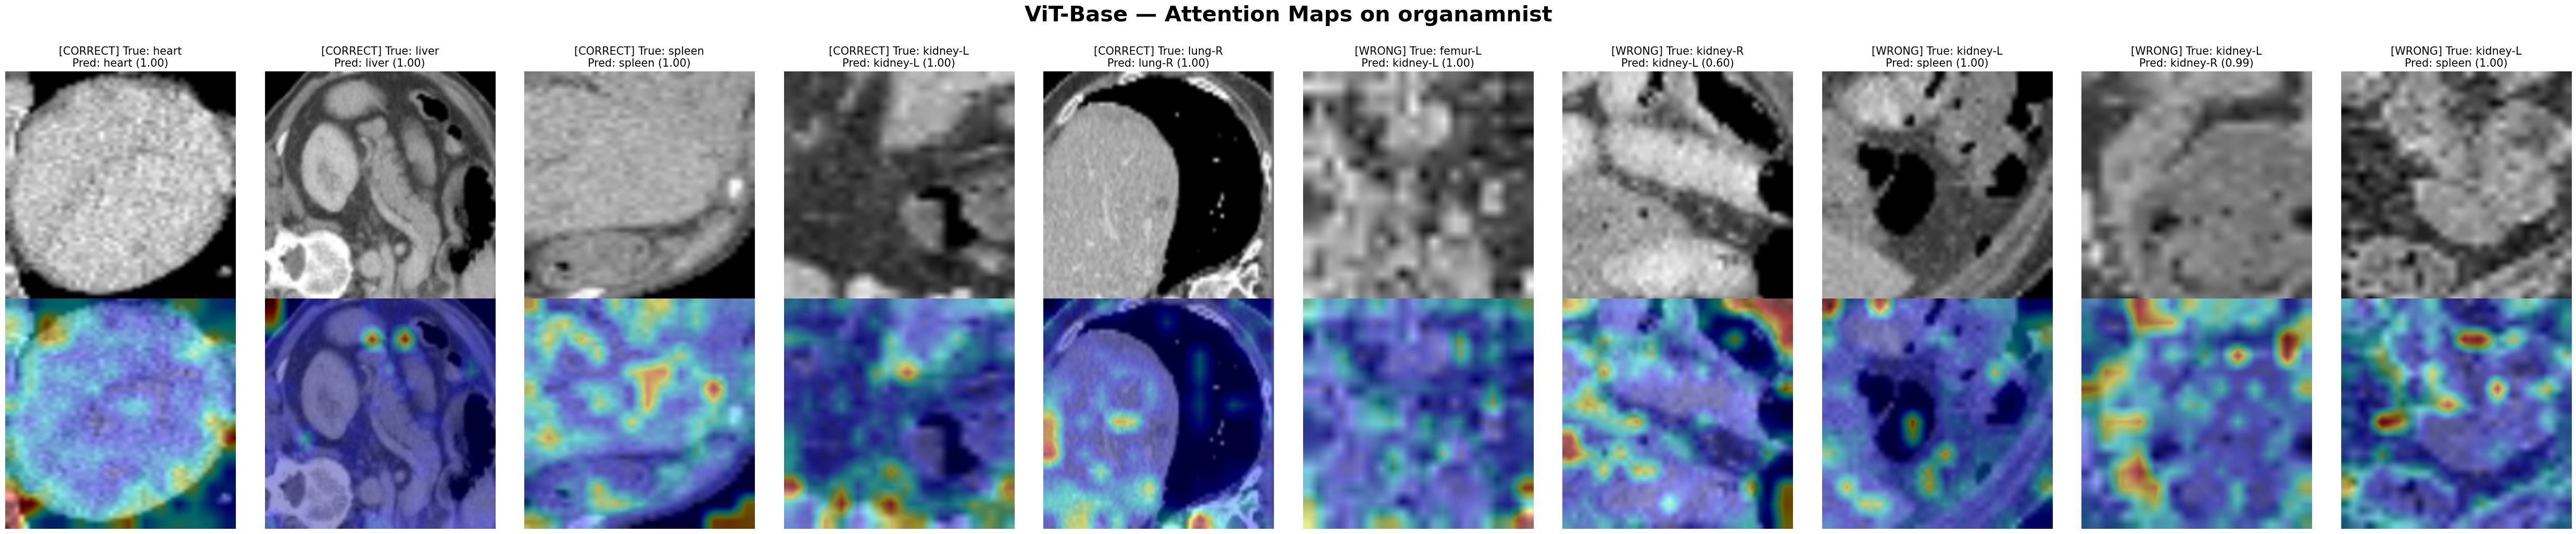

  Saved: ./organamnist_interpretability/ViT-Base_attention.png / .tif / .svg


In [6]:
print(f"\n{'='*70}")
print(f"ViT-Base Attention Maps")
print(f"{'='*70}")

vit_path = f"{INPUT_DIR}/ViT-Base_{DATASET}.keras"

if not os.path.exists(vit_path):
    print(f"  SKIP — model file not found: {vit_path}")
elif 'ViT-Base' not in test_preds:
    print(f"  SKIP — predictions not loaded")
else:
    # Build architecture and capture the backbone reference
    print("  Building ViT-Base with backbone reference...")
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.Rescaling(1./127.5, offset=-1)(inputs)
    x = layers.Permute((3, 1, 2))(x)

    vit_backbone = TFViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224', num_labels=n_classes,
        ignore_mismatched_sizes=True, use_safetensors=False
    )

    vit_out = vit_backbone.vit(x)[0]
    logits = vit_backbone.classifier(vit_out[:, 0, :])
    probs_out = layers.Activation('softmax', dtype='float32')(logits)
    vit_model = models.Model(inputs=inputs, outputs=probs_out, name='ViT-Base')

    # Load trained weights — this updates vit_backbone in place
    print(f"  Extracting raw weights from {vit_path}...")
    temp_h5_path = f"{INPUT_DIR}/ViT_temp.h5"
    
    try:
        # Extract the raw HDF5 weights from the Keras 3 archive
        with zipfile.ZipFile(vit_path, 'r') as z:
            with open(temp_h5_path, 'wb') as f:
                f.write(z.read('model.weights.h5'))
        
        # Load the raw weights by name, ignoring Keras 3 JSON configs
        vit_model.load_weights(temp_h5_path, by_name=True)
        print(f"  Weights loaded successfully")
        
    except Exception as e:
        print(f"  ERROR loading ViT weights: {e}")
    finally:
        # Clean up the temporary file
        if os.path.exists(temp_h5_path):
            os.remove(temp_h5_path)

    # Select samples
    probs = test_preds['ViT-Base']
    y_pred = np.argmax(probs, axis=1)
    sample_idx = select_samples(y_pred, y_test, N_CORRECT, N_WRONG)
    n_samples = len(sample_idx)

    print(f"  Generating attention maps for {n_samples} samples...")

    fig, axes = plt.subplots(2, n_samples, figsize=(5 * n_samples, 10))
    if n_samples == 1:
        axes = axes.reshape(2, 1)

    for col, idx in enumerate(sample_idx):
        raw_img = X_test_raw[idx]
        img_for_model = prepare_image_for_model(raw_img, MODEL_INPUT_SIZE)
        img_display = get_display_image(raw_img, MODEL_INPUT_SIZE)

        try:
            # Preprocess manually 
            img_normalized = img_for_model / 127.5 - 1.0
            img_permuted = np.transpose(img_normalized, (2, 0, 1))  # (C, H, W)
            img_batch = img_permuted[np.newaxis, ...]  # (1, C, H, W)
            img_tensor = tf.constant(img_batch, dtype=tf.float32)

            # Call backbone.vit directly with output_attentions=True
            vit_output = vit_backbone.vit(img_tensor, output_attentions=True)
            attentions = vit_output.attentions  # tuple of 12 layers

            # Last layer attention, average over 12 heads
            # Shape: (1, 12, 197, 197) → average over heads → (1, 197, 197)
            last_attn = attentions[-1].numpy()
            avg_attn = np.mean(last_attn, axis=1)[0]  # (197, 197)

            # CLS token attention to patch tokens (exclude CLS-to-CLS)
            cls_attn = avg_attn[0, 1:]  # (196,)

            # Reshape to spatial grid: 224/16 = 14 patches per dimension
            attn_map = cls_attn.reshape(14, 14)
            attn_map = cv2.resize(attn_map, (MODEL_INPUT_SIZE, MODEL_INPUT_SIZE))
            attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-9)

            # Plot
            status = "CORRECT" if y_pred[idx] == y_test[idx] else "WRONG"
            true_name = CLASS_NAMES[y_test[idx]]
            pred_name = CLASS_NAMES[y_pred[idx]]
            conf = probs[idx, y_pred[idx]]

            axes[0, col].imshow(img_display)
            axes[0, col].set_title(f"[{status}] True: {true_name}\nPred: {pred_name} ({conf:.2f})", fontsize=15)
            axes[0, col].axis('off')

            overlay = overlay_heatmap(img_display, attn_map)
            axes[1, col].imshow(overlay)
            axes[1, col].axis('off')

        except Exception as e:
            print(f"  Error on sample {idx}: {e}")
            import traceback
            traceback.print_exc()
            axes[0, col].text(0.5, 0.5, f"Error:\n{str(e)[:50]}", ha='center', va='center',
                             transform=axes[0, col].transAxes, fontsize=8)
            axes[0, col].axis('off')
            axes[1, col].axis('off')

    plt.suptitle(f"ViT-Base — Attention Maps on {DATASET}", fontsize=30, y=1.02, weight='bold')
    plt.tight_layout()
    save_base = f"{OUTPUT_DIR}/ViT-Base_attention"
    save_all_formats(save_base)
    plt.show()
    print(f"  Saved: {save_base}.png / .tif / .svg")

    del vit_model, vit_backbone
    gc.collect()
    tf.keras.backend.clear_session()

## Summary

In [7]:
print(f"\n{'='*70}")
print(f"INTERPRETABILITY COMPLETE: {DATASET}")
print(f"{'='*70}")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"\nFiles generated:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    print(f"  {f:<50} {size_kb:.0f} KB")


INTERPRETABILITY COMPLETE: organamnist

Output directory: ./organamnist_interpretability

Files generated:
  ViT-Base_attention.png                             5308 KB
  ViT-Base_attention.svg                             2264 KB
  ViT-Base_attention.tif                             204335 KB
  collage.ipynb                                      9 KB
